# Dependency Packages

In [23]:
import mne
import numpy as np
from mne.channels import make_standard_montage
from mne.decoding import CSP
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold , train_test_split , GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
import os

# Dataset Setting

In [24]:
# Select dataset
# 0: BCICIV_2a
# 1: BCICIV_2b
Dataset_Selection = 0


match Dataset_Selection:
    case 0:
        gdf_dirPath = f'../../dataset/BCICIV_2a_gdf/' # GDF read dir path
        participants = [] # EEG-MI 受試者
        participantsNum = 9 # EEG-MI 受試者人數
        for i in range(1,participantsNum+1,1):
            participants = participants + [f'A0{i}T']  # bci4_2A
        saveResultPath = './result_bci4_2a/' # 結果儲存資料夾
        target_keys = ['769', '770'] # 任務Code, 769 左手, 770右手
        # BCI4 2A 資料集電擊轉換成標準10-20系統
        channel_rename_map = {
            'EEG-Fz' : 'Fz'  ,
            'EEG-0'  : 'FC3' ,
            'EEG-1'  : 'FC1' ,
            'EEG-2'  : 'FCz' ,
            'EEG-3'  : 'FC2' ,
            'EEG-4'  : 'FC4' ,
            'EEG-5'  : 'C5'  ,
            'EEG-C3' : 'C3'  ,
            'EEG-6'  : 'C1'  ,
            'EEG-Cz' : 'Cz'  ,
            'EEG-7'  : 'C2'  ,
            'EEG-C4' : 'C4'  ,
            'EEG-8'  : 'C6'  ,
            'EEG-9'  : 'CP3' ,
            'EEG-10' : 'CP1' ,
            'EEG-11' : 'CPz' ,
            'EEG-12' : 'CP2' ,
            'EEG-13' : 'CP4' ,
            'EEG-14' : 'P1'  ,
            'EEG-Pz' : 'Pz'  ,
            'EEG-15' : 'P2'  ,
            'EEG-16' : 'POz' ,
            'EOG-left'   : 'EOG-left',
            'EOG-central': 'EOG-central',
            'EOG-right'  : 'EOG-right'
        }
        channel_types = {
            'EEG-Fz' : 'eeg',
            'EEG-0'  : 'eeg',
            'EEG-1'  : 'eeg',
            'EEG-2'  : 'eeg',
            'EEG-3'  : 'eeg',
            'EEG-4'  : 'eeg',
            'EEG-5'  : 'eeg',
            'EEG-C3' : 'eeg',
            'EEG-6'  : 'eeg',
            'EEG-Cz' : 'eeg',
            'EEG-7'  : 'eeg',
            'EEG-C4' : 'eeg',
            'EEG-8'  : 'eeg',
            'EEG-9'  : 'eeg',
            'EEG-10' : 'eeg',
            'EEG-11' : 'eeg',
            'EEG-12' : 'eeg',
            'EEG-13' : 'eeg',
            'EEG-14' : 'eeg',
            'EEG-Pz' : 'eeg',
            'EEG-15' : 'eeg',
            'EEG-16' : 'eeg',
            'EOG-left'   : 'eog',
            'EOG-central': 'eog',
            'EOG-right'  : 'eog'
        }
    case 1:
        gdf_dirPath = f'../../dataset/BCICIV_2b_gdf/'
        participants = []
        participantsNum = 9
        for i in range(1,participantsNum+1,1):
            participants = participants + [f'B0{i}03T']  # bci4_2B
        saveResultPath = './result_bci4_2b/'
        target_keys = ['769', '770'] # 任務Code, 769 左手, 770右手
        # BCI4 2B 資料集電擊轉換成標準10-20系統
        channel_rename_map = {
            'EEG:C3' : 'C3'  ,
            'EEG:Cz' : 'Cz'  ,
            'EEG:C4' : 'C4'  ,
            'EOG:ch01':'EOG:ch01',
            'EOG:ch02':'EOG:ch02',
            'EOG:ch03':'EOG:ch03'
        }
        channel_types = {
            'EEG:C3'   : 'eeg',
            'EEG:Cz'   : 'eeg',
            'EEG:C4'   : 'eeg',
            'EOG:ch01' : 'eog',
            'EOG:ch02' : 'eog',
            'EOG:ch03' : 'eog'
        }

try:
    os.mkdir(saveResultPath) # 創建結果儲存資料夾
except:
    print("file exist")
    pass

file exist


# Pre-Processing Setting

In [25]:
# band pass filter
sfreq = 250
lowcut = 8
highcut = 11
filter_order = 4
filter_type = 'butter' # Butterworth
iir_params = dict(order=filter_order, ftype=filter_type)

# 擷取實驗時間，0秒是cued開始
tmin = 0
tmax = 2

# CSP M值
M = 3

# Filter Response Analysis

In [26]:
# iir_coeffs = mne.filter.create_filter(
#     data=None,           # data=None 時，僅計算係數
#     sfreq=sfreq,
#     l_freq=lowcut,
#     h_freq=highcut,
#     method='iir',
#     iir_params=iir_params,
# )

# f = mne.viz.plot_filter(
#     iir_coeffs,
#     sfreq=sfreq,
#     freq=[lowcut, highcut],
#     fscale = "linear",
#     alim = (-5,1),
#     plot= ('magnitude', 'delay'),
#     title=f'Butterworth Filter Frequency Response (Order={filter_order}, {lowcut}-{highcut} Hz)'
# )
# title=f'Butterworth Filter Frequency Response (Order={filter_order}, {lowcut}-{highcut} Hz)'
# name = title.split(' ')
# name = '_'.join(name) + ".png"
# savePath = saveResultPath + f'./{name}'
# f.savefig(savePath)

# print()

# Data Segmentation and Splitting

In [27]:
montage = make_standard_montage('standard_1020')
eeg_only_channels = [
    name
    for name in channel_rename_map.values()
    if not name.startswith('EOG')
]

## Create Epoch training data and testing data
LHepochs = {}
RHepochs = {}
SEED = 42
for subject in participants:
    gdf_filepath = gdf_dirPath + f'./{subject}.gdf'
    try:
        raw = mne.io.read_raw_gdf(gdf_filepath, preload=True)
        print("GDF 檔案讀取成功。")
    except Exception as e:
        print(f"讀取 GDF 檔案時發生錯誤: {e}")
        raise
    ## Raw setting
    raw.set_channel_types(channel_types) # 設定電擊種類是EEG還是EOG
    raw.set_eeg_reference([]) # 設定reference電擊
    raw.rename_channels(channel_rename_map) # 重新命名電擊名稱符合10-20系統
    raw.set_montage(montage, on_missing='ignore') # 設定10-20系統

    ## Regression
    # model = mne.preprocessing.EOGRegression(picks='eeg', picks_artifact='eog')
    # model.fit(raw)
    # raw = model.apply(raw)

    raw.pick_channels(eeg_only_channels) # Remove EOG data
    raw.filter( # Bandpass filter
        l_freq=lowcut,
        h_freq=highcut,
        method='iir',
        iir_params=iir_params
    )

    ## 選取事件做成epoch
    events, event_id = mne.events_from_annotations(raw)
    kept_event_ids = {
        key: value
        for key, value in event_id.items()
        if key in ['769']
    }
    events_of_interest = events[np.isin(events[:, 2], list(kept_event_ids.values()))]
    baseline = None # 不做基線校正，或您可以定義 (-0.5, 0)
    LHepoch = mne.Epochs(
        raw,
        events_of_interest,
        event_id=kept_event_ids,
        tmin=tmin,
        tmax=tmax,
        baseline=baseline,
        preload=True,        # 將數據載入內存
        proj=False           # 暫時不應用投影
    )
    kept_event_ids = {
        key: value
        for key, value in event_id.items()
        if key in ['770']
    }
    events_of_interest = events[np.isin(events[:, 2], list(kept_event_ids.values()))]
    RHepoch = mne.Epochs(
        raw,
        events_of_interest,
        event_id=kept_event_ids,
        tmin=tmin,
        tmax=tmax,
        baseline=baseline,
        preload=True,        # 將數據載入內存
        proj=False           # 暫時不應用投影
    )

    LHepochs[subject] = LHepoch
    RHepochs[subject] = RHepoch

Extracting EDF parameters from d:\User\Desktop\EEGsProgram\dataset\BCICIV_2a_gdf\A01T.gdf...
GDF file detected


Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 672527  =      0.000 ...  2690.108 secs...


C:\Users\User\AppData\Local\Programs\Python\Python310\lib\contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


GDF 檔案讀取成功。
EEG channel type selected for re-referencing
EEG data marked as already having the desired reference.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 11 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 8.00, 11.00 Hz: -6.02, -6.02 dB

Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]
Not setting metadata
72 matching events found
No baseline correction applied
Using data from preloaded Raw for 72 events and 501 original time points ...
0 bad epochs dropped
Not setting metadata
72 matching events found
No baseline correction applied
Using data from preloaded Raw for 72 events a

C:\Users\User\AppData\Local\Programs\Python\Python310\lib\contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


...

GDF 檔案讀取成功。
EEG channel type selected for re-referencing
EEG data marked as already having the desired reference.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 11 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 8.00, 11.00 Hz: -6.02, -6.02 dB

Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]
Not setting metadata
72 matching events found
No baseline correction applied
Using data from preloaded Raw for 72 events and 501 original time points ...
0 bad epochs dropped
Not setting metadata
72 matching events found
No baseline correction applied
Using data from preloaded Raw for 72 events a

C:\Users\User\AppData\Local\Programs\Python\Python310\lib\contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


GDF 檔案讀取成功。
EEG channel type selected for re-referencing
EEG data marked as already having the desired reference.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 11 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 8.00, 11.00 Hz: -6.02, -6.02 dB

Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]
Not setting metadata
72 matching events found
No baseline correction applied
Using data from preloaded Raw for 72 events and 501 original time points ...
0 bad epochs dropped
Not setting metadata
72 matching events found
No baseline correction applied
Using data from preloaded Raw for 72 events a

C:\Users\User\AppData\Local\Programs\Python\Python310\lib\contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


GDF 檔案讀取成功。
EEG channel type selected for re-referencing
EEG data marked as already having the desired reference.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 11 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 8.00, 11.00 Hz: -6.02, -6.02 dB

Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]
Not setting metadata
72 matching events found
No baseline correction applied
Using data from preloaded Raw for 72 events and 501 original time points ...
0 bad epochs dropped
Not setting metadata
72 matching events found
No baseline correction applied
Using data from preloaded Raw for 72 events a

# 原始資料分析

(501,)
(501,)
(501,)
(501,)
(501,)
(501,)
(501,)
(501,)
(501,)


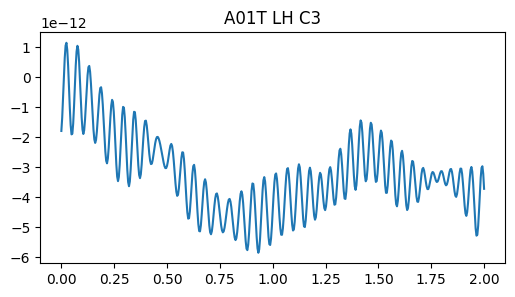

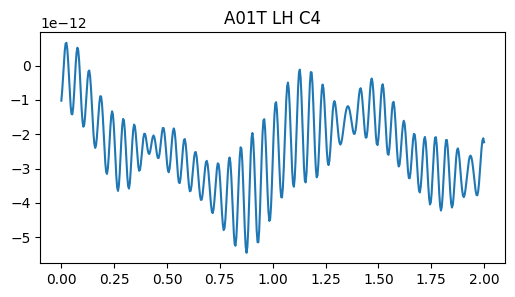

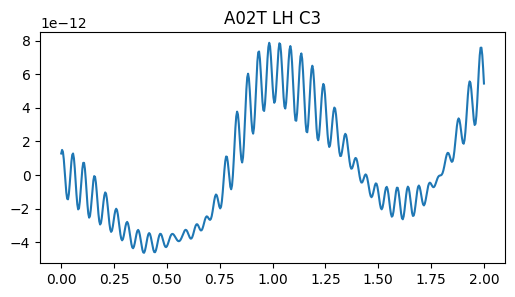

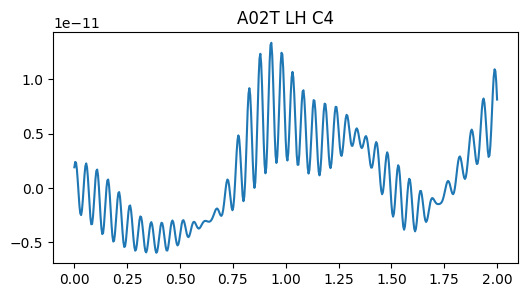

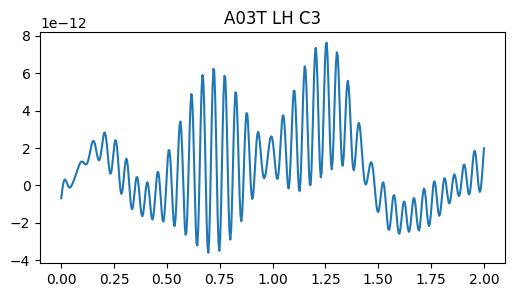

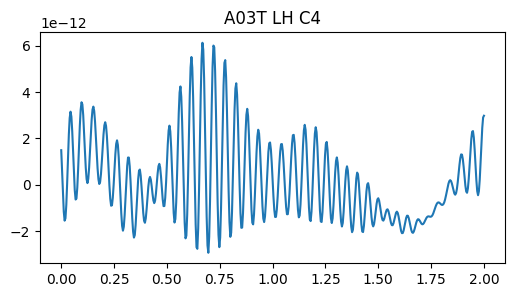

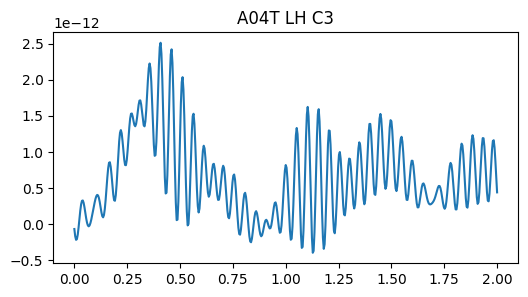

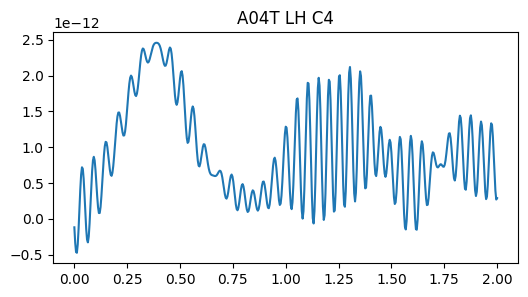

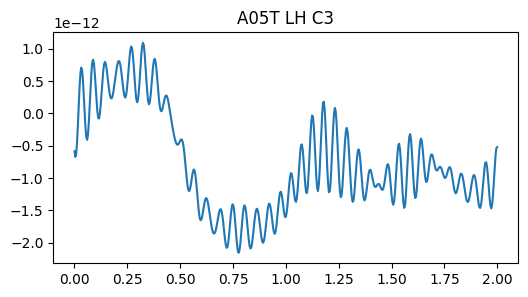

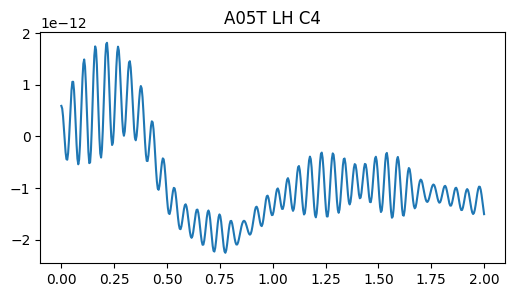

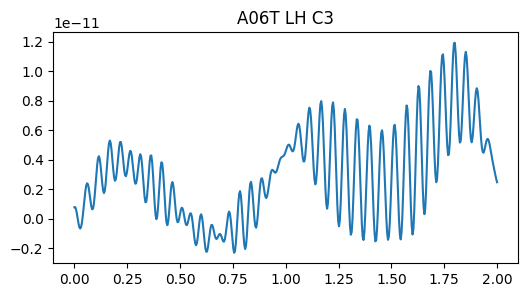

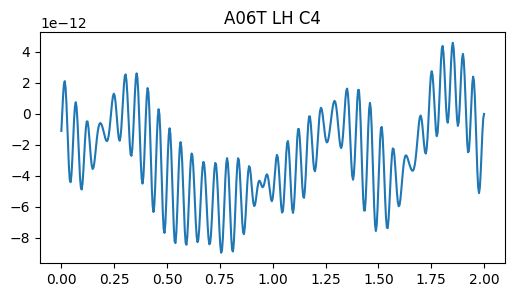

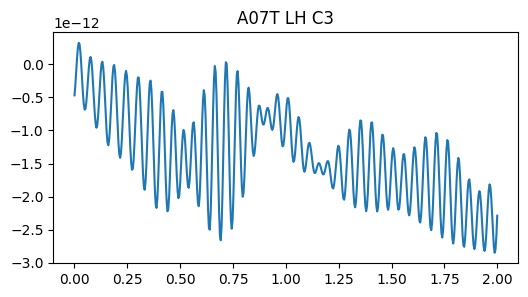

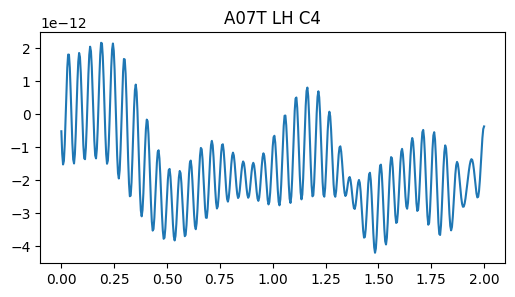

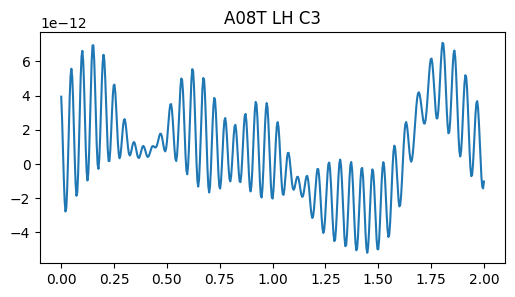

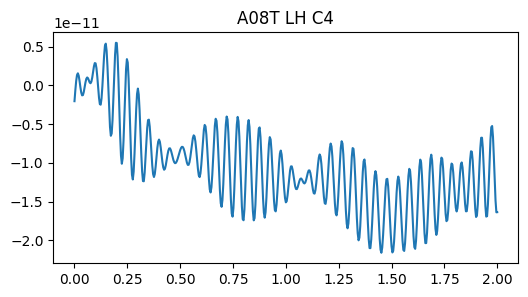

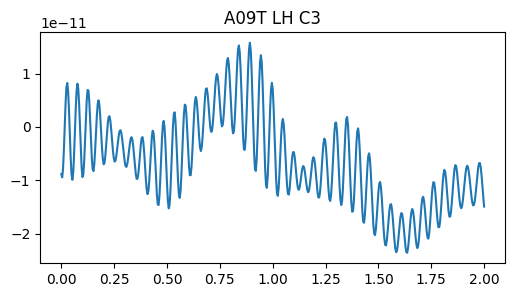

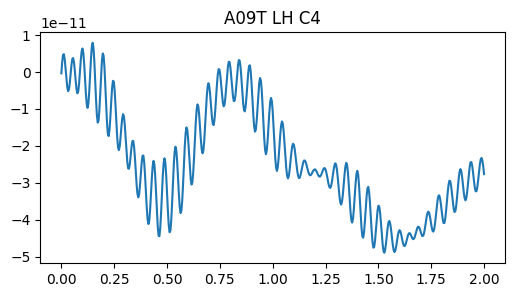

In [28]:
subject = 'A08T'
for subject in participants:
    data = LHepochs[subject].get_data()
    trialsNum = data.shape[0]
    times = LHepochs[subject].times
    chs = LHepochs[subject].ch_names
    C3_position = chs.index('C3')
    C4_position = chs.index('C4')
    # fig, ax = plt.subplots(10,1)
    # for trial in range(trialsNum):
    #     fig = plt.figure(figsize=(6,0.5))
    #     power = data[trial,C3_position,:] ** 2
    #     plt.plot(times, power)
    #     plt.show

    bad_trials = []
    for trial in range(trialsNum):
        d = data[trial, C3_position,:]
        if d.max()-d.min() > 50e-6:
            # print(trial)
            bad_trials.append(trial)

    data1 = np.delete(data, bad_trials, axis=0)
    power = data1[:, C3_position,:] ** 2
    powerMean = power.mean(0)
    baseline = powerMean[0:10].mean()
    powerMean = powerMean - baseline
    fig = plt.figure(figsize=(6,3))
    plt.plot(times, powerMean)
    plt.title(f"{subject} LH C3")
    plt.show

    ################

    data = LHepochs[subject].get_data()
    trialsNum = data.shape[0]
    times = LHepochs[subject].times
    chs = LHepochs[subject].ch_names
    C3_position = chs.index('C3')
    C4_position = chs.index('C4')
    # fig, ax = plt.subplots(10,1)
    # for trial in range(trialsNum):
    #     fig = plt.figure(figsize=(6,0.5))
    #     power = data[trial,C4_position,:] ** 2
    #     plt.plot(times, power)
    #     plt.show

    bad_trials = []
    for trial in range(trialsNum):
        d = data[trial, C4_position,:]
        if d.max()-d.min() > 200e-6:
            # print(trial)
            bad_trials.append(trial)

    data2 = np.delete(data, bad_trials, axis=0)
    power = data2[:, C4_position,:] ** 2
    powerMean = power.mean(0)
    baseline = powerMean[0:10].mean()
    powerMean = powerMean - baseline
    print(powerMean.shape)
    fig = plt.figure(figsize=(6,3))
    plt.plot(times, powerMean)
    plt.title(f"{subject} LH C4")
    plt.show